<a href="https://colab.research.google.com/github/mjkloeckner/TB065/blob/main/tpe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico Especial

Señales y Sistemas (TB065) - Curso 2 - Grupo 11 - 1C2025 - FIUBA  
Martin Klöckner - mklockner@fi.uba.ar  
Pablo Martinez Madero - pmartinezm@fi.uba.ar  
Ernesto Dei Castelli - edei@fi.uba.ar  

### Introducción

El habla humana puede ser entendida y analizada mediante modelos de sistemas lineales e invariantes en el tiempo (sistemas LTI). En este trabajo se considera la señal de voz como la salida de un sistema. La respuesta de este sistema varía en función de la fuente de la voz y la “configuración” del tracto vocal.

Cuando la señal tiene la forma de un tren de pulsos, la salida tiene un patrón periódico lo que corresponde a sonidos vocálicos, como por ejemplo la el sonido `[a]`. Cuando se ve una señal ruidosa, se pueden identificar sonidos fricativos, como por ejemplo el sonido `[s]`.

Se realiza un análisis de la señal donde se identifican estas diferencias a partir de una visualización en el dominio del tiempo y posteriormente, en el dominio de la frecuencia mediante el uso de la transformada rápida de Fourier (FFT) la cual nos permite extraer la frecuencia fundamental (f0) y los formantes.

### Obtención y Gráfico de Muestras

Para comenzar, como señal de muestra se realiza la grabación de dos muestras de voz, una rápida y una lenta pronunciando la palabra “Picasso”, de manera tal que la segunda tenga aproximadamente el doble de duracion que la primera, luego se procede a graficar las señales en el dominio del tiempo para lograr identificar regiones periódicas y no periódicas.

Para la realización de los gráficos se utiliza el lenguaje de programación
[python](https://www.python.org) junto con las librerías
[scipy](https://docs.scipy.org/doc/scipy/index.html),
[matplotlib](https://matplotlib.org/) y
[numpy](https://numpy.org/doc/stable/index.html).

Para empezar se importan las librerías mencionadas previamente en un script
de python, incluyendo el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) del módulo [urllib.request](https://docs.python.org/3/library/urllib.request.html#module-urllib.request) para obtener localmente los archivos a analizar.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.io import wavfile
from urllib.request import urlretrieve

Para obtener los archivos a analizar, se define una variable para almacenar el nombre de los archivos y se descargan utilizando el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) proporcionando las respectivas urls y el nombre final que se desea que tengan los archivos una vez descargados.

In [2]:
short_sample_file_name = 'picasso_short.wav'
long_sample_file_name = 'picasso_long.wav'

urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/data/picasso_short.wav', short_sample_file_name);
urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/data/picasso_long.wav', long_sample_file_name);

Continuamos leyendo el contenido del primer archivo de nombre `picasso_short.wav`, para lo cual se utiliza el método [wavfile.read](https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.read.html#read) de la librería [scipy](https://docs.scipy.org/doc/scipy/index.html). Esta función devuelve los datos y la tasa de muestreo leidos del archivo en formato WAV cuyo nombre recibe como argumento.

In [3]:
short_sample_fs, short_sample_data = wavfile.read(short_sample_file_name)

Para graficar los datos obtenidos resulta conveniente definir la función `graph_data`, la cual utiliza métodos del módulo [pyplot](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot) de la librería [matplotlib](https://matplotlib.org/) para generar los gráficos pedidos. Esto además permite evitar patrones repetitivos en el código,

In [4]:
def graph_data(x, y, title, figure_number=0, t=0, dt=0, a=0, da=0, stem=False, tick=0):
  figure, axis = plt.subplots(num=title, figsize=(12, 6))
  figure_caption = 'Figura ' + str(figure_number) + ': ' + title
  figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)

  if stem == True:
    plt.stem(x, y, label='Coeficientes de la Serie de Fourier', basefmt=" ")
  else:
    plt.plot(x, y, label='Señal de Audio')

  axis.set(xlabel='Tiempo [s]' if stem == False else "Frecuencia [Hz]", ylabel='Amplitud')
  plt.grid(True)
  plt.legend()
  plt.xlim([t, t+dt if t != 0 else x[-1]])
  axis.axvspan(a, a+da, color='skyblue', alpha=0 if a == 0 else 0.50) # resaltado

  if tick != 0:
    from matplotlib.ticker import MultipleLocator
    plt.gca().xaxis.set_major_locator(MultipleLocator(tick))

  plt.show()

Para poder graficar los datos se necesita saber a qué tiempo corresponde cada valor de la señal; para eso, se utiliza el método [arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html#numpy-arange) de la libreria [numpy](https://numpy.org/doc/stable/index.html). Este método devuelve un arreglo de números equidistantes del largo que recibe como parámetro, en este caso del largo de los datos leídos del archivo. Para convertirlo a segundos se divide por la tasa de muestreo, la cual también se obtiene cuando se lee el archivo.

In [5]:
short_sample_time = np.arange(len(short_sample_data)) / short_sample_fs

Se define una variable para almacenar el título de la figura, esto para posteriormente pasarlo como argumento a la función `graph_data`.

In [6]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'

Finalmente se grafica el pimer archivo utilizando la funcion `graph_data`

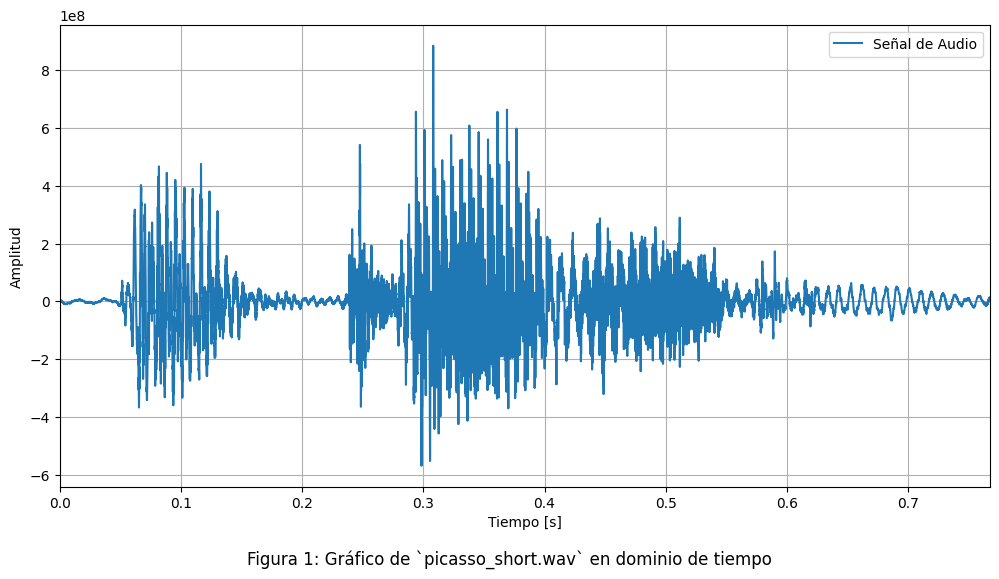

In [7]:
graph_data(short_sample_time, short_sample_data, title, 1)

Ahora realizamos exactamente el mismo procedimiento para el segundo archivo de aproximadamente el doble de duración.

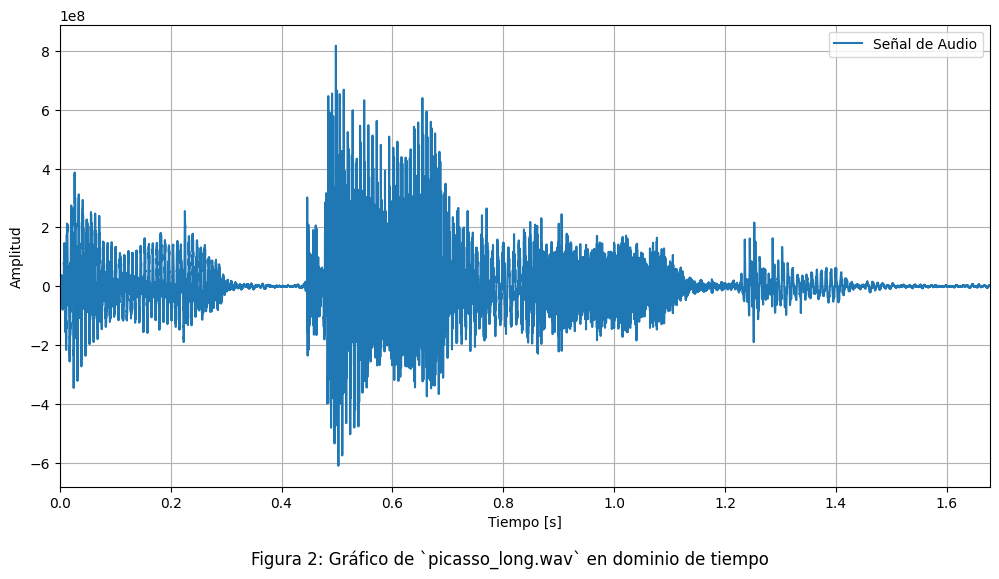

In [8]:
long_sample_fs, long_sample_data = wavfile.read(long_sample_file_name)
long_sample_time = np.arange(len(long_sample_data)) / long_sample_fs
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 2)

## Analisis Visual en Dominio de Tiempo

Haciendo una inspeccion visual de las señales graficadas en las figuras 1 y 2, se identifican ciertas partes que tienen un patron que se repite despues de un intervalo de tiempo.

Para el primer archivo, se toma como ejemplo el intervalo entre `0.08` y `0.12` en los cuales se observa un periódo que parece repetirse cada `0.0093s`, esto resulta en una frecuencia de aproximadamente `107.5Hz`; dicho intervalo de la señal se puede ver en figura 3, en la cual también se resalta el período fundamental de la misma.

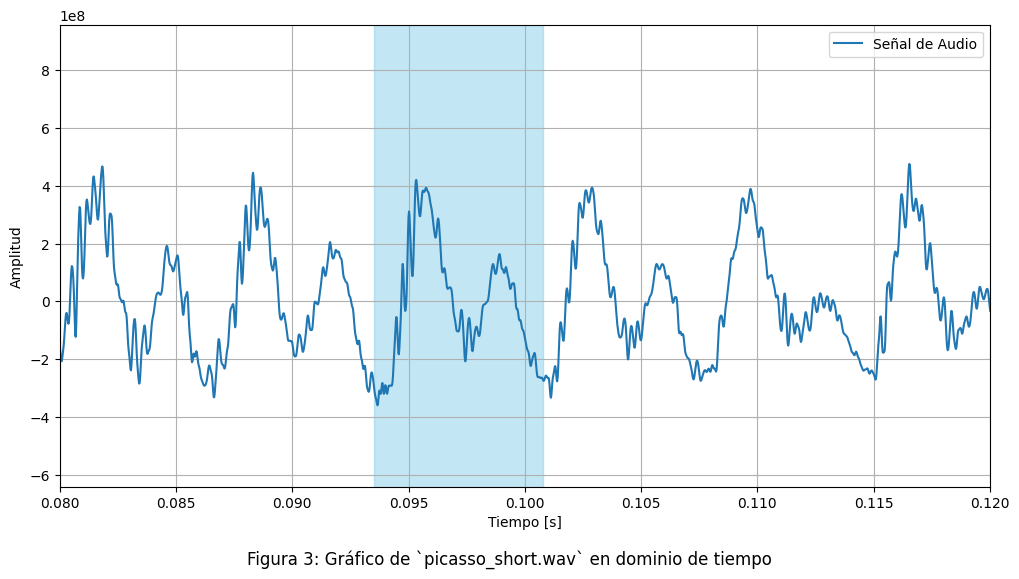

In [9]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 3, t=0.08, dt=0.04, a=0.0935, da=0.0073)

De manera analoga para el segundo archivo, de mayor duración, se realiza una inspección visual de la señal, en este caso se toma el intervalo entre `0.08s` y `0.120s` como se observa en la figura 4, además en la misma se grafica el periodo fundamental el cual resulta aproximadamente `0.00756s`, resultando en una frecuencia aproximada de `132.3Hz`

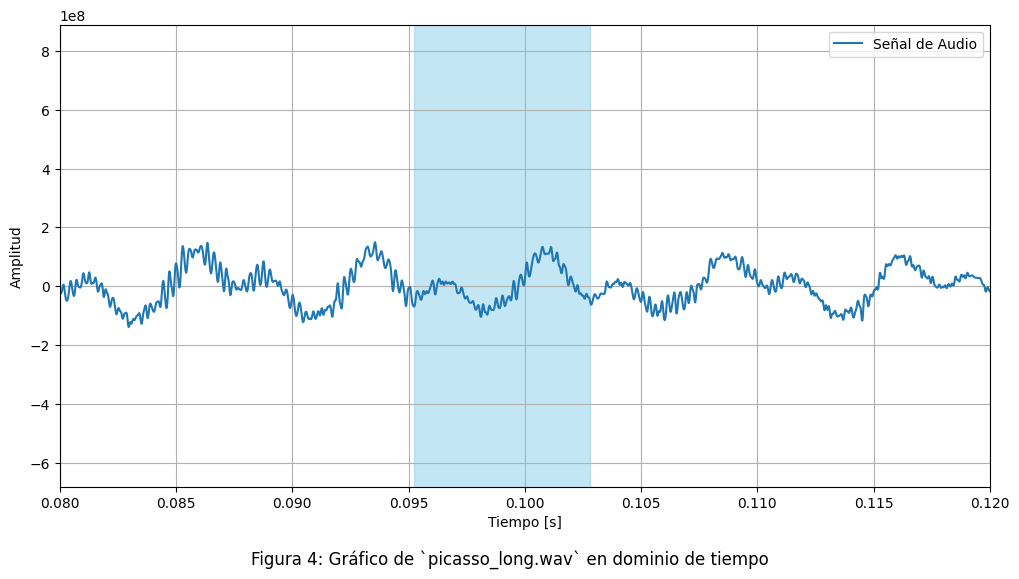

In [10]:
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 4, t=0.08, dt=0.04, a=0.09525, da=0.00756)

Realizando un analisis similar en busca de intervalos peridicos, se realiza una inspeccion visual de la señal, pero esta vez buscando patrones no repetitivos.

A continuación se muestra un intervalo de la señal del archivo corto, en donde la señal resulta no períodica, se puede ver que si bien parece haber un patron repetitivo y asemejar a una señal senoidal, no se puede considerar períodica porque la señal montada, o ruido, no es periodico, por lo que la señal resultante no lo es.

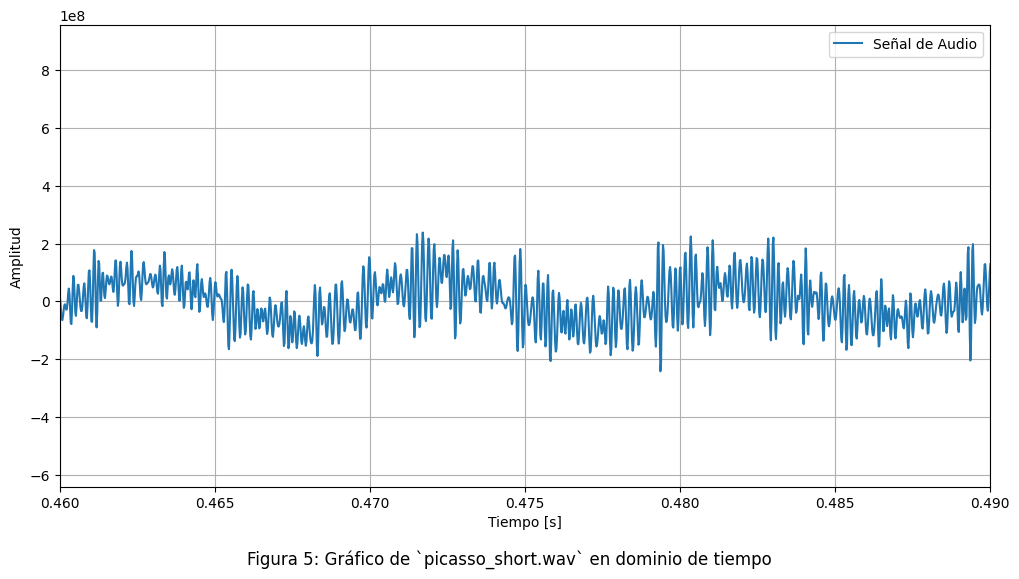

In [11]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 5, t=0.46, dt=0.03);

Para el archivo largo se toma el intervalo entre `0.445s` y `0.460` como ejemplo de intervalo no periodico de la señal, este intervalo se puede ver en la figura 6 a continuación.

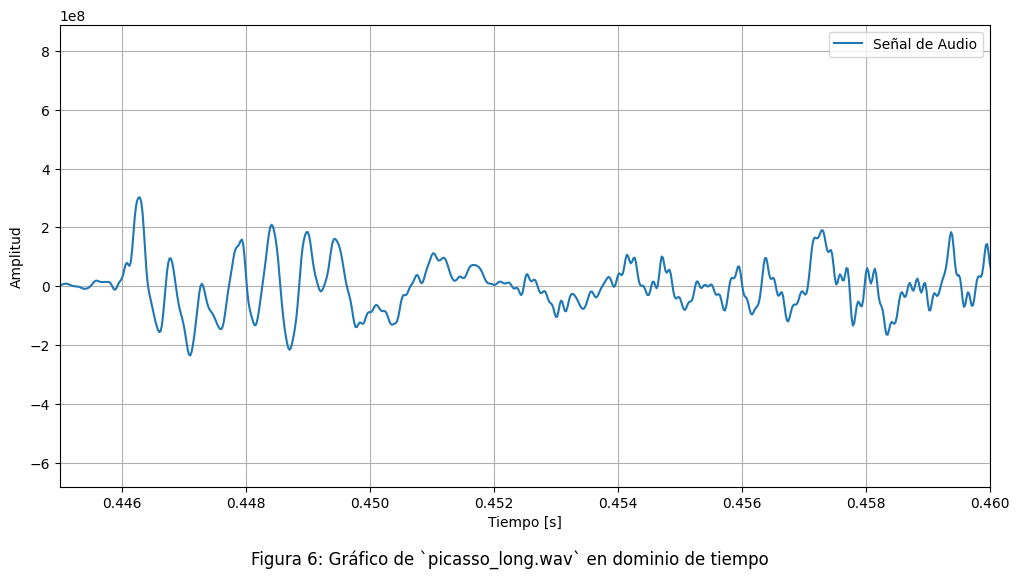

In [12]:
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data, title, 6, t=0.445, dt=0.015)

### Identificación de las sonidos vocalicos

En la figura 7 el grafico resaltado corresponde con el sonido vocalico `[a]` ya que se asemeja a un tren de impulsos cuasi-periodico.

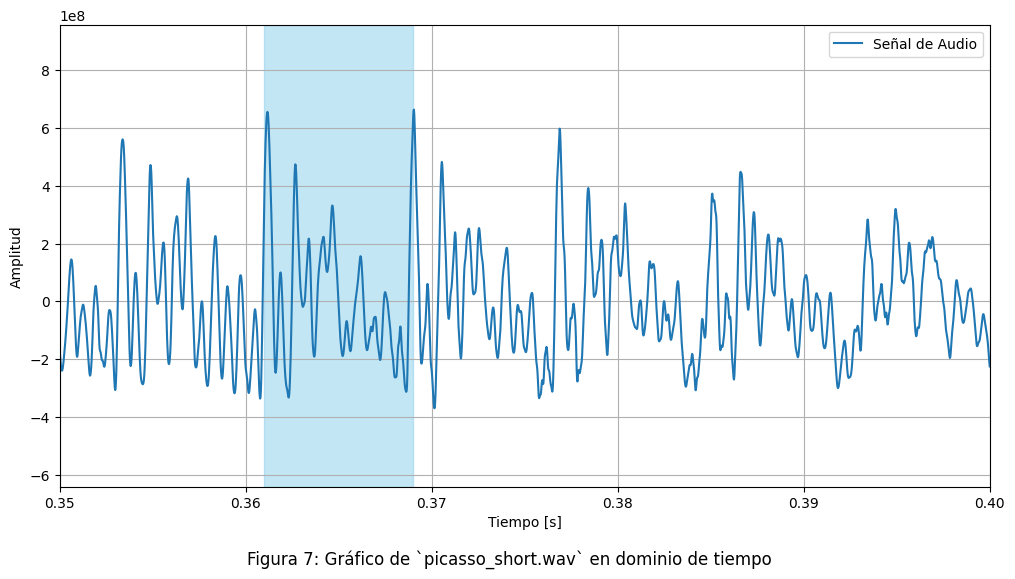

In [13]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data, title, 7, t=0.35, dt=0.05, a=0.361, da=0.008);

El sonido vocalico `[s]` corresponde con una señal de entrada del sistema de ruido blanco, este patron se identifica en la figura 6, en la cual se puede ver una señal senoidal la cual parece tener montada una señal de ruidosa.

## Analisis en Frecuencia

Para calcular los coeficientes de Fourier, se utiliza los metodos [fft](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fft.html#scipy.fft.fft) y [fftfreq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fftfreq.html#fftfreq) del modulo [fft](https://docs.scipy.org/doc/scipy/reference/fft.html#discrete-fourier-transforms-scipy-fft) de la libreria [scipy](https://docs.scipy.org/doc/scipy/index.html). Se define la funcion `graph_fourier` la cual permite graficar tanto los coeficientes de la serie de Fourier del intervalo definido por `[x, y]` como la transformada de la misma, para el mismo intervalo.

In [14]:
from scipy.fft import fft, fftfreq

def graph_fourier(data, fs, t, dt, title, fig_num, f_max, coef=False, ticks=0):
  interval_data = data[int(t*fs):int((t+dt)*fs)]
  interval_fft = fft(interval_data)
  interval_freqs = fftfreq(len(interval_data), d=1/fs)

  # Se toma la parte positiva en ambos casos (primer parte del arreglo)
  x = interval_freqs[:len(interval_data) // 2]
  y = np.abs(interval_fft[:len(interval_data) // 2])

  graph_data(x, y, title, fig_num, 0.01 if f_max != 0 else 0, f_max, stem=coef, tick=ticks)

La palabra "Picasso" pronunciada en el archivo de muestra cuenta con 3 vocales: "a", "i" y "o", ya identificamos el intervalo en donde se pronuncia la "a", el cual se muestra en la figura 7, a continuación se utiliza la funcion `graph_fourier` definida previamente para calcular los coeficientes de fourier, utilizando el intervalo `[0.361, 0.369]` en el cual se encuentra un solo periodo de la señal periodica producto de pronunciar la "a".

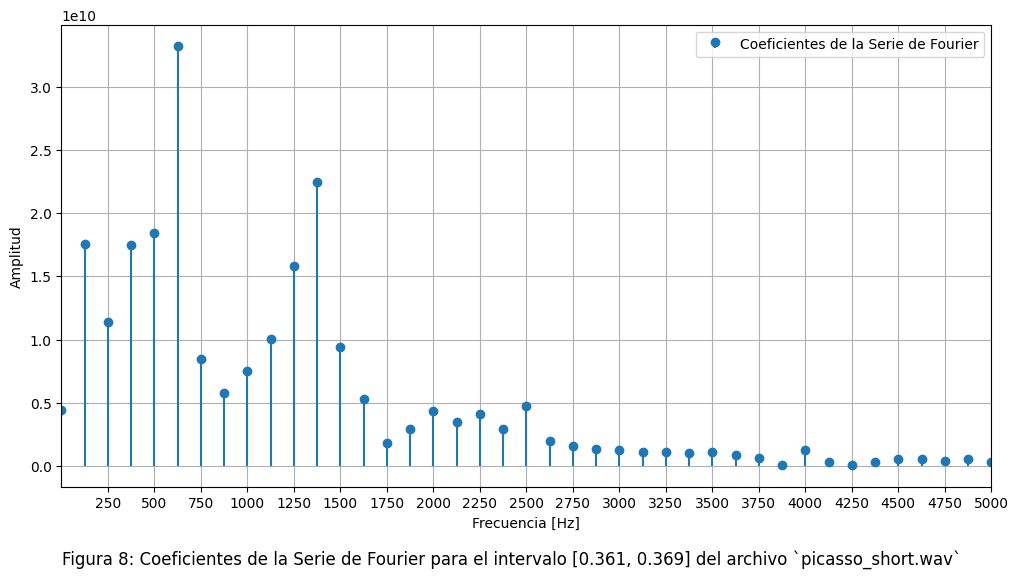

In [15]:
t=0.361
dt=0.008 # 0.361 + 0.008 = 0.369
title = f'Coeficientes de la Serie de Fourier para el intervalo [{t}, {t+dt}] del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 8, 5000, coef=True, ticks=250)

Tomando 4 periodos de la señal, los coeficientes de Fourier resultan como se ve en la figura 9 a continuación, se puede ver que tiene mucho mas "detalle" que la figura 7, en la cual se tomaba solo un periodo para realizar la FFT

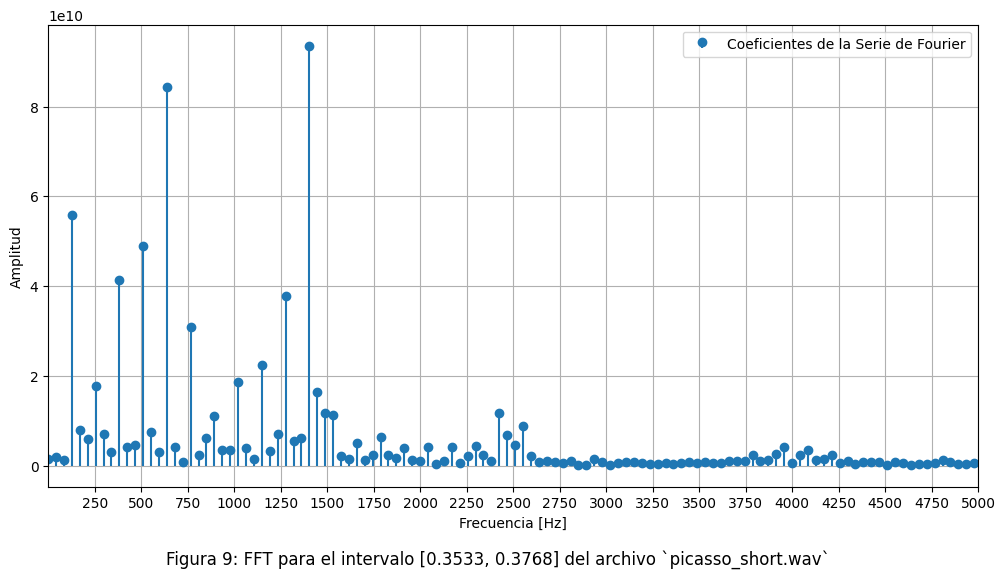

In [16]:
t=0.3533
dt=0.0235
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 9, 5000, coef=True, ticks=250)

Para la segunda vocal "i", se identifica en la señal el intervalo `[0.087, 0.094]s` el cual corresponde con el periodo de una señal periodica. Calculando los coeficientes de Fourier para dicho período resulta como se muestra a continuación en la figura 10.

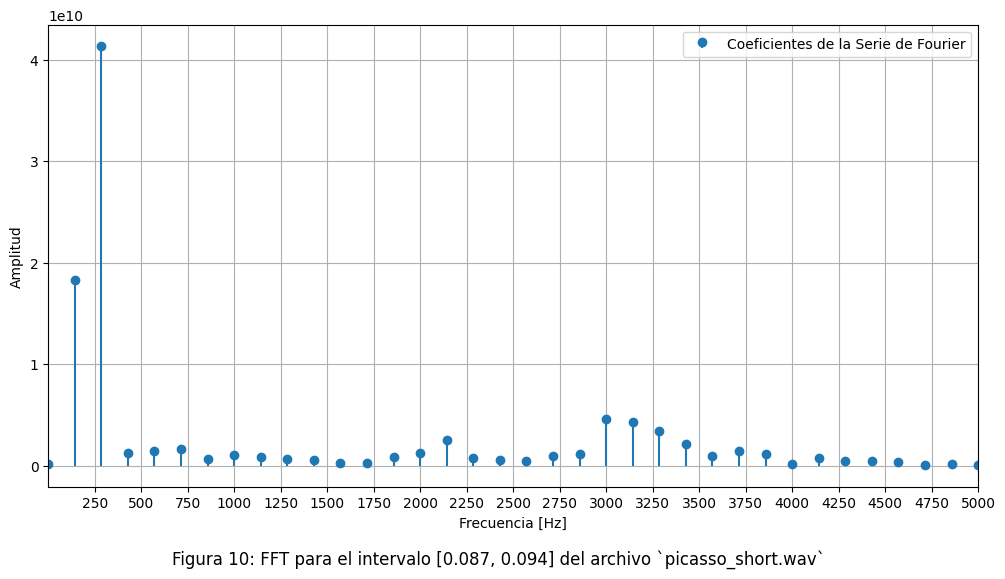

In [18]:
t=0.087
dt=0.007
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 10, 5000, coef=True, ticks=250)

Tomando ahora 5 periodos de la señal, por ejemplo el intervalo entre `[0.087, 0.122]`, los coeficientes de la serie de Fourier resultan como se muestra en la figura 11.

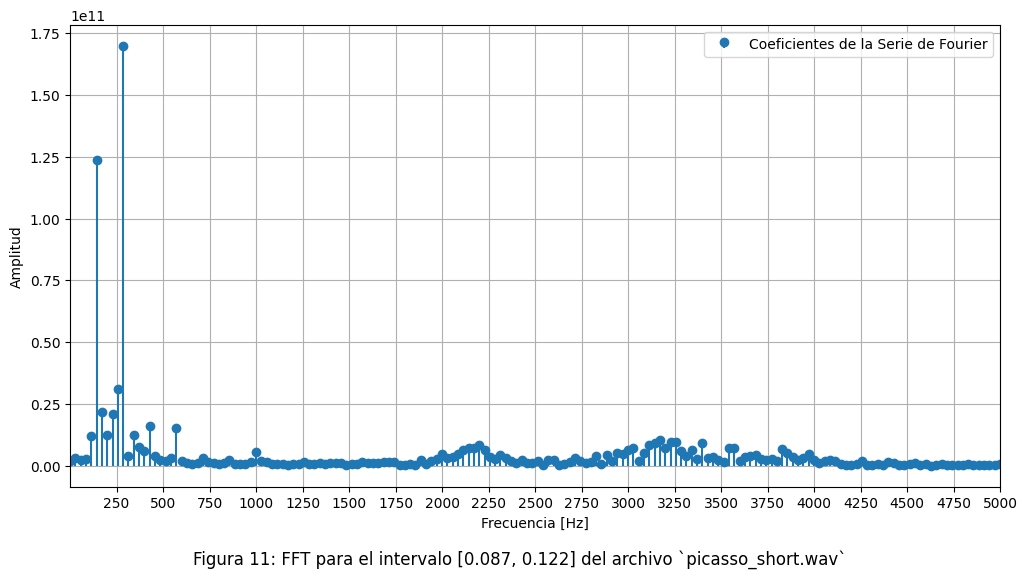

In [19]:
t=0.087
dt=5*0.007
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 11, 5000, coef=True, ticks=250)

Finalmente, para  la vocal "o", se identifica el intervalo `[0.634, 0.643]s`, graficando los coeficientes de Fourier, resultan como en la figura 12 a continuación.

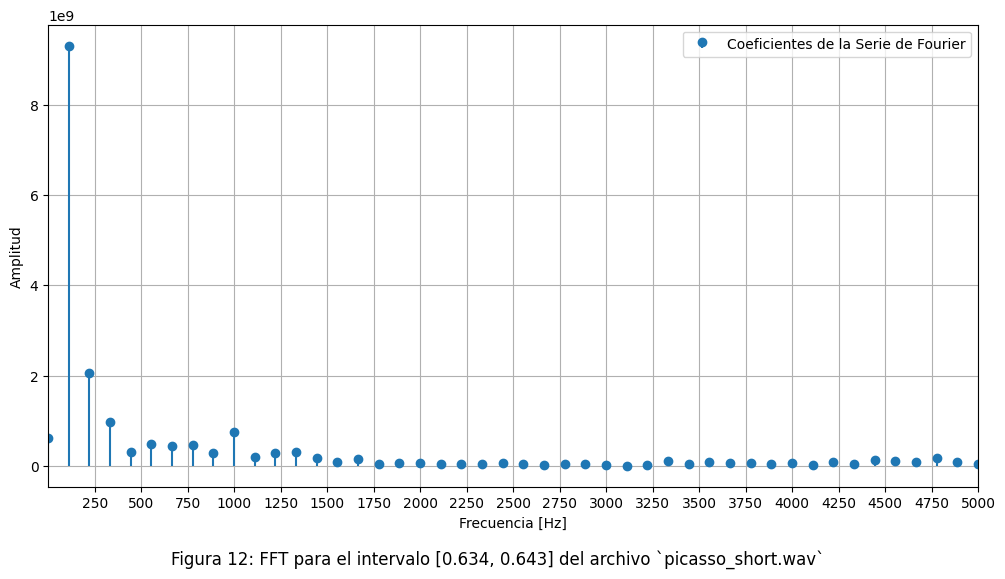

In [21]:
t=0.634
dt=0.009
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 12, 5000, coef=True, ticks=250)

Y tomando mas periodos, por ejemplo para aproximadamente 6 periodos, se toma el intervalo `[0.634, 0.588]s`, el grafico de los coeficientes de Fourier resulta como se muestra en la figura 13.

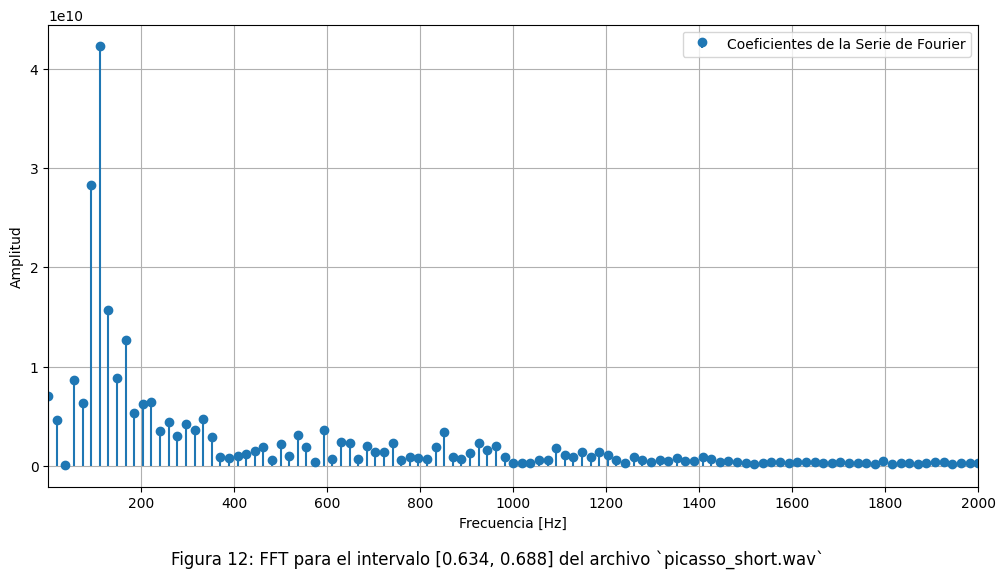

In [32]:
t=0.634
dt=6*0.009
title = f'FFT para el intervalo [{t}, {t+dt}] del archivo `{short_sample_file_name}`'
graph_fourier(short_sample_data, short_sample_fs, t, dt, title, 12, 2000, coef=True, ticks=200)